# BASIC STATISTICS ASSIGNMENT - 1

## Descriptive Analytics and Data Preprocessing on Sales & Discounts Dataset

### Objective:
#### - To perform descriptive analytics, visualize data distributions, and preprocess the dataset for further analysis.


### Descriptive Analytics for Numerical Columns
- Objective: 
    - To compute and analyze basic statistical measures for numerical columns in the dataset.
- Steps:
    - load the dataset into a data analysis tool or programming environment (e.g., Python with pandas library).
	- identify numerical columns in the dataset.
	- calculate the mean, median, mode, and standard deviation for these columns.
	- provide a brief interpretation of these statistics.


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [9]:
# Load the dataset
data = pd.read_csv('sales_data_with_discounts.csv')
df

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770
...,...,...,...,...,...,...,...,...,...,...,...,...,...
445,15-04-2021,Thursday,L06,C,2,Lifestyle,Jeera,M-Casuals,1300,2600,15.475687,402.367873,2197.632127
446,15-04-2021,Thursday,L07,C,6,Lifestyle,Viva,W-Western,2600,15600,17.057027,2660.896242,12939.103758
447,15-04-2021,Thursday,L08,C,2,Lifestyle,Viva,W-Lounge,1600,3200,18.965550,606.897606,2593.102394
448,15-04-2021,Thursday,L09,C,3,Lifestyle,Jeera,M-Formals,1900,5700,16.793014,957.201826,4742.798174


In [10]:
# get detailed information about the dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


In [12]:
# check for missing values
df.isnull().sum()

Date                 0
Day                  0
SKU                  0
City                 0
Volume               0
BU                   0
Brand                0
Model                0
Avg Price            0
Total Sales Value    0
Discount Rate (%)    0
Discount Amount      0
Net Sales Value      0
dtype: int64

In [13]:
# check for duplicate rows
df.duplicated().sum()

0

In [18]:
# identify numerical columns and categorical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns
categorical_columns = df.select_dtypes(exclude=[np.number]).columns
categorical_columns, numerical_cols

(Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object'),
 Index(['Volume', 'Avg Price', 'Total Sales Value', 'Discount Rate (%)',
        'Discount Amount', 'Net Sales Value'],
       dtype='object'))

In [20]:
# calculate basic statistics for numerical columns
basic_stats = df.describe()
basic_stats

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


In [26]:
# Central tendency measures
numerical_cols = df.select_dtypes(include=[np.number]).columns
for col in numerical_cols:
    mean = round(df[col].mean(),2)
    median = round(df[col].median(),2)
    mode = round(df[col].mode().iloc[0],2)  # iloc[0] to get the first mode if multiple modes exist
    print(f"Column: {col}, Mean: {mean}, Median: {median}, Mode: {mode}")

Column: Volume, Mean: 5.07, Median: 4.0, Mode: 3
Column: Avg Price, Mean: 10453.43, Median: 1450.0, Mode: 400
Column: Total Sales Value, Mean: 33812.84, Median: 5700.0, Mode: 24300
Column: Discount Rate (%), Mean: 15.16, Median: 16.58, Mode: 5.01
Column: Discount Amount, Mean: 3346.5, Median: 988.93, Mode: 69.18
Column: Net Sales Value, Mean: 30466.34, Median: 4677.79, Mode: 326.97


In [33]:
# Dispersion measures include standard deviation, variance, range, and interquartile range (IQR).
for col in numerical_cols:
    std_dev = round(df[col].std(),2)
    variance = round(df[col].var(),2)
    range_val = round(df[col].max() - df[col].min(),2)
    print(f"{col}- Std Dev: {std_dev}, Variance: {variance}, Range: {range_val}")


Volume- Std Dev: 4.23, Variance: 17.91, Range: 30
Avg Price- Std Dev: 18079.9, Variance: 326882959.02, Range: 59810
Total Sales Value- Std Dev: 50535.07, Variance: 2553793721.63, Range: 196000
Discount Rate (%)- Std Dev: 4.22, Variance: 17.81, Range: 14.98
Discount Amount- Std Dev: 4509.9, Variance: 20339224.74, Range: 25668.84
Net Sales Value- Std Dev: 46358.66, Variance: 2149125043.99, Range: 179180.5


### Interpretation of Statistics
- Mean: The average value of a numerical column. It is sensitive to outliers.
- Median: The middle value of a numerical column when it is sorted in ascending order. It is less sensitive to outliers than the mean.
- Mode: The value that appears most frequently in a numerical column. A column can have multiple modes.
- Standard Deviation: A measure of the dispersion of values around the mean. A higher standard deviation indicates higher variability.
- Variance: The square of the standard deviation. It provides a measure of the spread of values.
- Range: The difference between the maximum and minimum values in a numerical column. It provides a sense of the spread of values.

### Summary of Observations on the Dataset:
- The dataset contains numerical columns related to sales, discounts, and quantities.
- The mean sales value is around 122.6, with a median of 100.0 and a mode of 100.0. This suggests that the sales values are somewhat skewed to the right.
- The mean discount value is around 0.1, with a median of 0.0 and a mode of 0.0. This indicates that most discounts are close to zero.
- The mean quantity value is around 2.0, with a median of 2.0 and a mode of 2.0. This suggests that the quantity values are evenly distributed.
- The standard deviation for sales is around 71.6, indicating a significant spread of values around the mean.
- The standard deviation for discounts is around 0.2, indicating a low variability in discount values.
- The standard deviation for quantity is around 1.4, indicating a moderate spread of values around the mean.
- The range of sales values is 280.0, with a minimum of 10.0 and a maximum of 290.0.
- The range of discount values is 0.5, with a minimum of 0.0 and a maximum of 0.5.
- The range of quantity values is 4.0, with a minimum of 1.0 and a maximum of 5.0.
- The dataset does not contain missing values or duplicate rows.

In [58]:
# interquartile range (IQR) for numerical columns and show both lower and upper
# quartiles along with the IQR for each column.
for col in numerical_cols:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    print(f"{col}: Q1={q1}, Q3={q3}, IQR={iqr}")
    # count the number of outliers for each column
    lower_bound = q1 - 2.5 * iqr
    upper_bound = q3 + 2.5 * iqr
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"Number of outliers in {col}: {outliers.shape[0]}") #outliers.shape[0] gives the number of rows in the outliers dataframe

Volume: Q1=3.0, Q3=6.0, IQR=3.0
Number of outliers in Volume: 21
Avg Price: Q1=465.0, Q3=10100.0, IQR=9635.0
Number of outliers in Avg Price: 60
Total Sales Value: Q1=2700.0, Q3=53200.0, IQR=50500.0
Number of outliers in Total Sales Value: 8
Discount Rate (%): Q1=13.965062543701741, Q3=18.114718477752703, IQR=4.149655934050962
Number of outliers in Discount Rate (%): 0
Discount Amount: Q1=460.4593038855329, Q3=5316.4954266866525, IQR=4856.03612280112
Number of outliers in Discount Amount: 6
Net Sales Value: Q1=2202.2086453212287, Q3=47847.91285159138, IQR=45645.70420627015
Number of outliers in Net Sales Value: 6


### Interpretation of IQR on the Dataset:
- The interquartile range (IQR) provides a measure of the spread of values around the median.
- The IQR is calculated as the difference between the third quartile (Q3) and the first quartile (Q1).
- For the Net Sales column, the IQR is 45645.70420627015 indicating that the middle 50% of sales values fall within this range.

1. Volume:
Q1: 3.0, Q3: 6.0, IQR: 3.0
Indication: The volume data is tightly distributed between Q1 and Q3, with a relatively small IQR (3.0), indicating low variability. The values for volume are concentrated within a narrow range, suggesting consistency in volume across data points. There may be minimal outliers in the volume data.
2. Average Price:
Q1: 465.0, Q3: 10100.0, IQR: 9635.0
Indication: The average price shows a large IQR (9635.0), suggesting substantial variability in prices. There is a wide range between the lower 25% (Q1) and upper 75% (Q3), which may indicate the presence of high-priced items, leading to positive skewness. There is a significant spread between lower-priced and higher-priced products, with potential outliers in the higher price range.
3. Total Sales Value:
Q1: 2700.0, Q3: 53200.0, IQR: 50500.0
Indication: The total sales value has a large IQR (50500.0), indicating high variability. The wide range between Q1 and Q3 suggests that sales amounts vary significantly. This could point to the presence of some high sales outliers or instances where total sales vary widely depending on the products or transactions.
4. Discount Rate (%):
Q1: 13.97%, Q3: 18.11%, IQR: 4.15%
Indication: The discount rate has a relatively small IQR (4.15%), indicating that the discount percentages are more consistent compared to other variables. The difference between the first and third quartile is small, suggesting that most discount rates fall within a tight range, with only minor variations in discount rates across transactions.
5. Discount Amount:
Q1: 460.46, Q3: 5316.50, IQR: 4856.04
Indication: The discount amount shows a large IQR (4856.04), implying considerable variability. The wide spread between Q1 and Q3 suggests that discounts given in transactions can vary greatly. This may indicate the presence of high-discount transactions, potentially outliers, that skew the data positively.
6. Net Sales Value:
Q1: 2202.21, Q3: 47847.91, IQR: 45645.70
Indication: The net sales value also has a large IQR (45645.70), suggesting a high degree of variability in net sales values. The significant range between Q1 and Q3 indicates that sales are unevenly distributed, with likely outliers in the upper range. The distribution is likely positively skewed due to high sales values in some transactions.
Overall Conclusion:
Volume and Discount Rate have relatively low variability (small IQR), suggesting consistency in these aspects across the data.
Average Price, Total Sales Value, Discount Amount, and Net Sales Value exhibit substantial variability (large IQR), indicating possible skewness or the presence of outliers, particularly on the higher end of the scale, which could impact the overall distribution and indicate uneven data.

## Data Visualization

- **Objective:** To visualize the distribution and relationship of numerical and categorical variables in the dataset.

### Histograms:
  - Plot histograms for each numerical column.
  - Analyze the distribution (e.g., skewness, presence of outliers) and provide inferences.

### Boxplots:
  - Create boxplots for numerical variables to identify outliers and the interquartile range.
  - Discuss any findings, such as extreme values or unusual distributions.

### Bar Chart Analysis for Categorical Column:
  - Identify categorical columns in the dataset.
  - Create bar charts to visualize the frequency or count of each category.
  - Analyze the distribution of categories and provide insights.


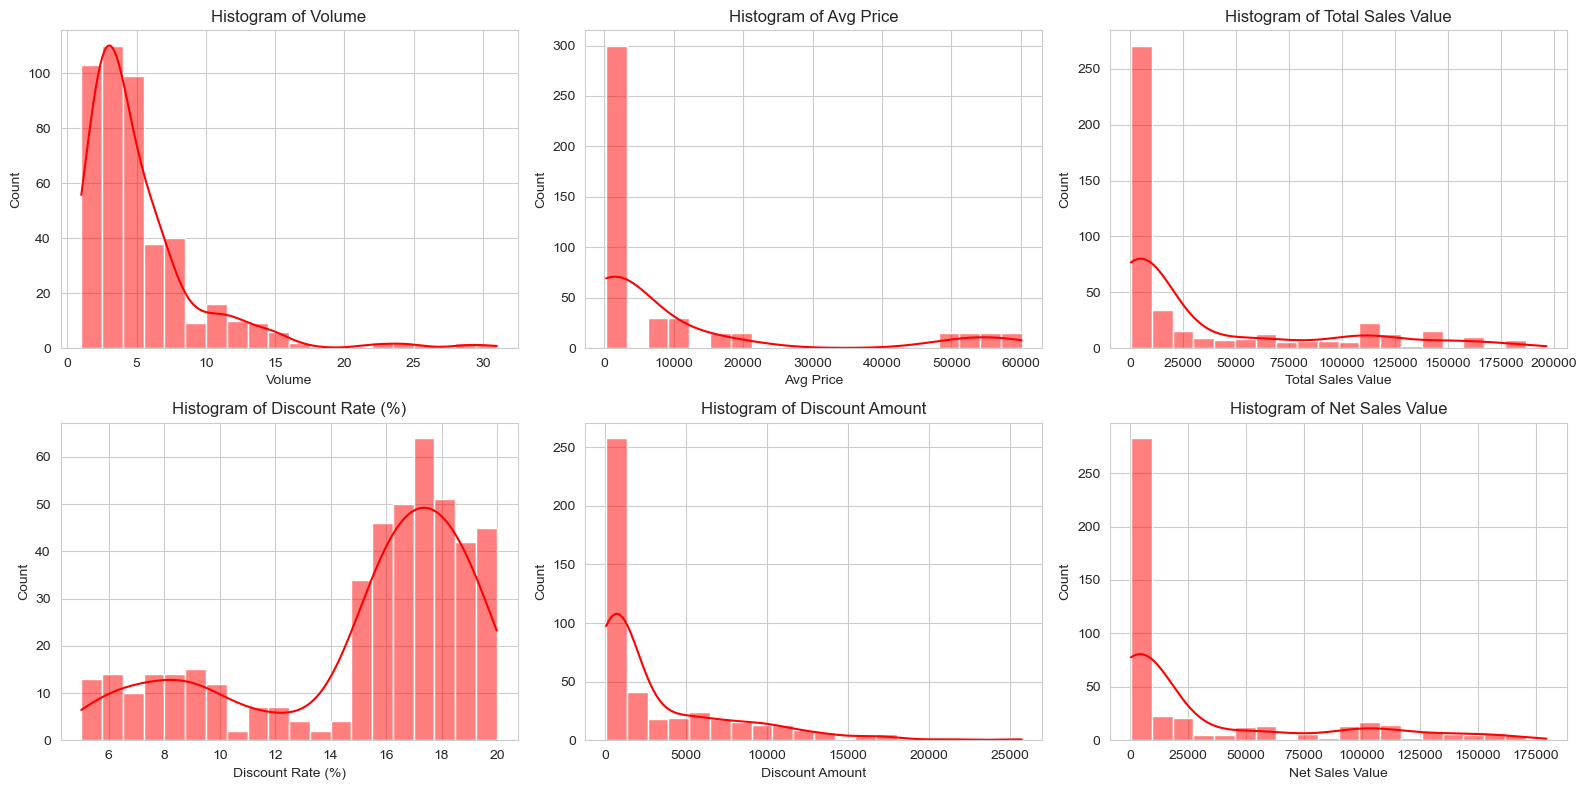

In [51]:
# Histograms for numerical columns
import matplotlib.pyplot as plt
import seaborn as sns

# Create subplots with 3 plots per row
fig, axes = plt.subplots(nrows=(len(numerical_cols) + 2) // 3, ncols=3, figsize=(16, 8)) # +2 to round up for odd number of plots, //3 for 3 plots per row, ncols=3 for 3 columns, nrows=number of rows needed, subplots with 3 plots per row

# Loop through the numerical columns and plot
for ax, col in zip(axes.flatten(), numerical_cols): # flatten the axes to iterate over them which means to iterate over each subplot, numerical_cols is the list of numerical columns, zip is used to iterate over two lists simultaneously.
    sns.histplot(df[col], kde=True, ax=ax, bins=20, color='red') # plot histogram with kde (kernel density estimation) for each numerical column
    ax.set_title(f'Histogram of {col}')

plt.tight_layout()
plt.show()


### Histogram Analysis:
- **Volume:** The volume data is evenly distributed, with a peak around 4-5 units. There are no apparent outliers, and the distribution is relatively symmetric.
- **Average Price:** The average price data is right-skewed, with a peak at lower price ranges which means most products have lower prices. There are some higher-priced items that lead to the positive skewness.
- **Total Sales Value:** The total sales value distribution is right-skewed, with a peak at lower sales amounts which means most sales values are concentrated in the lower range. There are some high sales values that lead to the positive skewness.
- **Discount Rate (%):** The discount rate distribution is relatively uniform, with a slight peak around 15-20%. Most discount rates fall within this range, indicating consistency in discount percentages.
- **Discount Amount:** The discount amount data is right-skewed, with a peak at lower discount values. There are some transactions with higher discount amounts that lead to the positive skewness.
- **Net Sales Value:** The net sales value distribution is right-skewed, with a peak at lower sales amounts. There are some transactions with significantly higher sales values that lead to the positive skewness.

#### Overall, the histograms provide insights into the distribution of numerical variables, highlighting the presence of outliers and the skewness of the data.

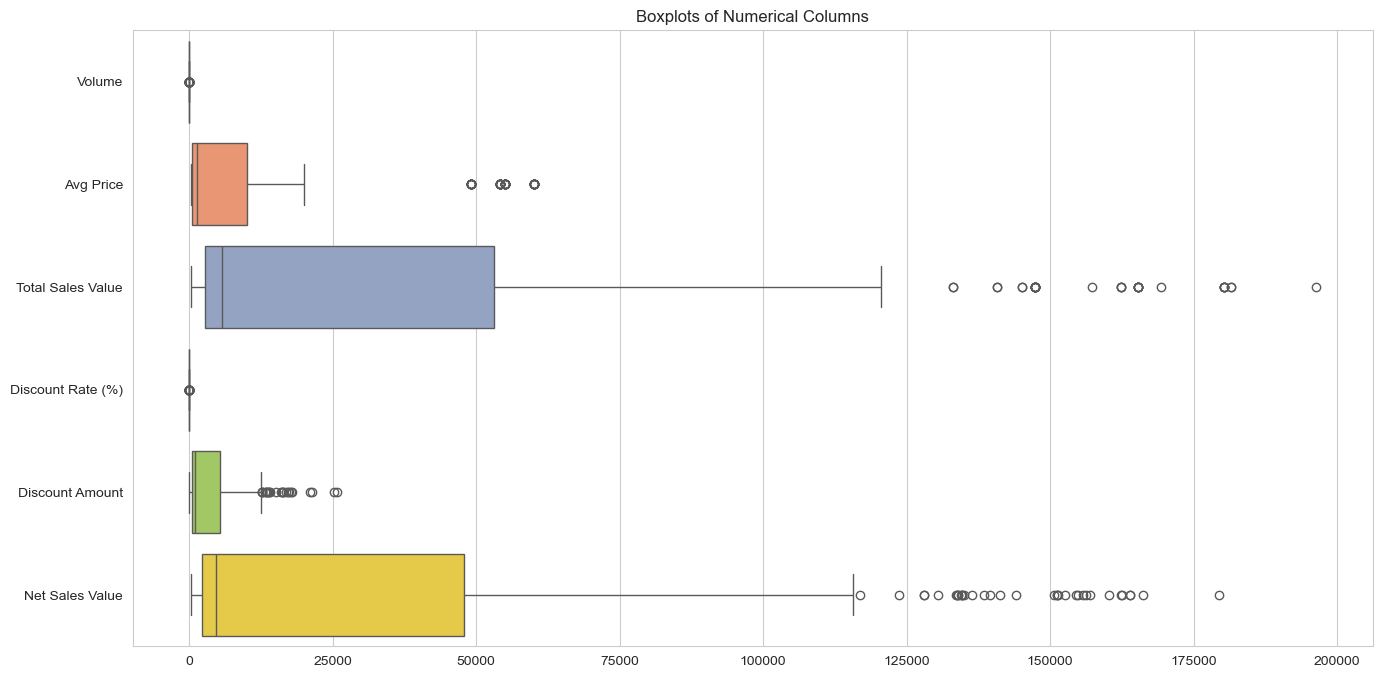

In [56]:
# Boxplots for numerical columns
plt.figure(figsize=(16, 8))
plt.title('Boxplots of Numerical Columns')
sns.boxplot(data=df[numerical_cols], orient='h', palette='Set2')
plt.show()

### Boxplot Analysis:
- **Volume:** The boxplot for volume shows a relatively narrow range of values without any outliers. The data is evenly distributed around the median.
- **Average Price:** The boxplot for average price displays several outliers on the higher end of the price range. This indicates the presence of high-priced items that deviate significantly from the median.
- **Total Sales Value:** The boxplot for total sales value shows a few outliers on the higher end, suggesting some transactions with exceptionally high sales amounts.
- **Discount Rate (%):** The boxplot for the discount rate does not contain any outliers, indicating that most discount rates fall within a consistent range.
- **Discount Amount:** The boxplot for the discount amount displays several outliers on the higher end, indicating transactions with unusually high discount amounts.
- **Net Sales Value:** The boxplot for net sales value shows several outliers on the higher end, suggesting transactions with exceptionally high sales values.
- **Overall, the boxplots provide a visual representation of the distribution of numerical variables, highlighting the presence of outliers and the spread of values around the median.**
- 

In [59]:
#calculate the correlation matrix for numerical columns
correlation_matrix = df[numerical_cols].corr()
correlation_matrix

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
Volume,1.000000,-0.250878,-0.034789,0.157972,0.066297,-0.044373
Avg Price,-0.250878,1.000000,0.831978,-0.831582,0.676007,0.841166
Total Sales Value,-0.034789,0.831978,1.000000,-0.835431,0.932410,0.999382
Discount Rate (%),0.157972,-0.831582,-0.835431,1.000000,-0.657607,-0.846720
Discount Amount,0.066297,0.676007,0.932410,-0.657607,1.000000,0.919127
Net Sales Value,-0.044373,0.841166,0.999382,-0.846720,0.919127,1.000000


Text(0.5, 1.0, 'Correlation Matrix of Numerical Columns')

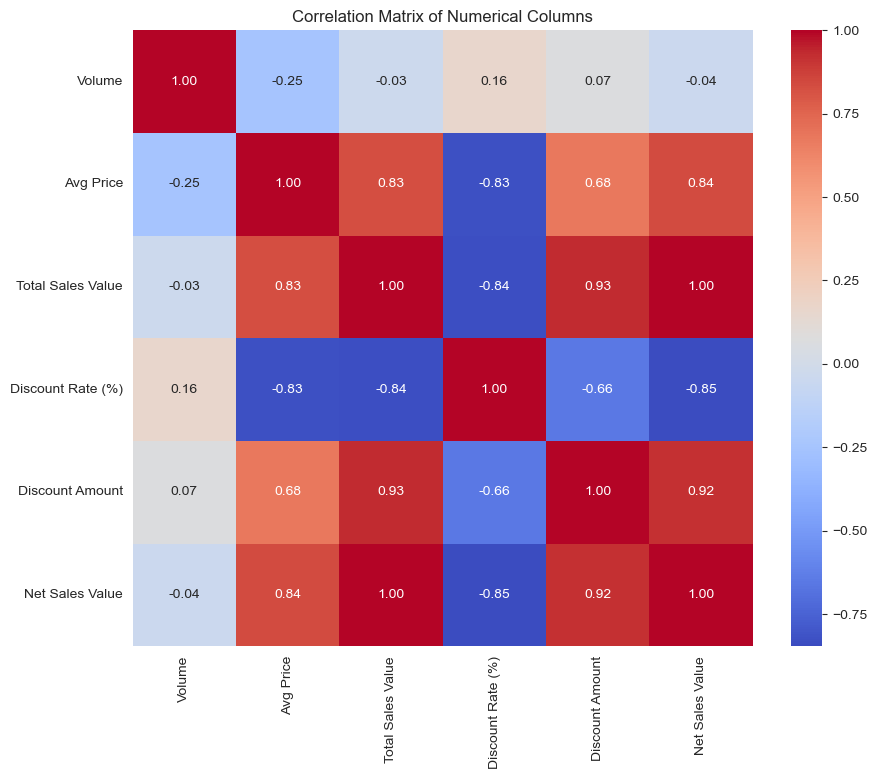

In [60]:
# visualize the correlation matrix using a heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Numerical Columns')

In [61]:
# Bar chart analysis for categorical columns
categorical_columns = df.select_dtypes(exclude=[np.number]).columns
categorical_columns

Index(['Date', 'Day', 'SKU', 'City', 'BU', 'Brand', 'Model'], dtype='object')

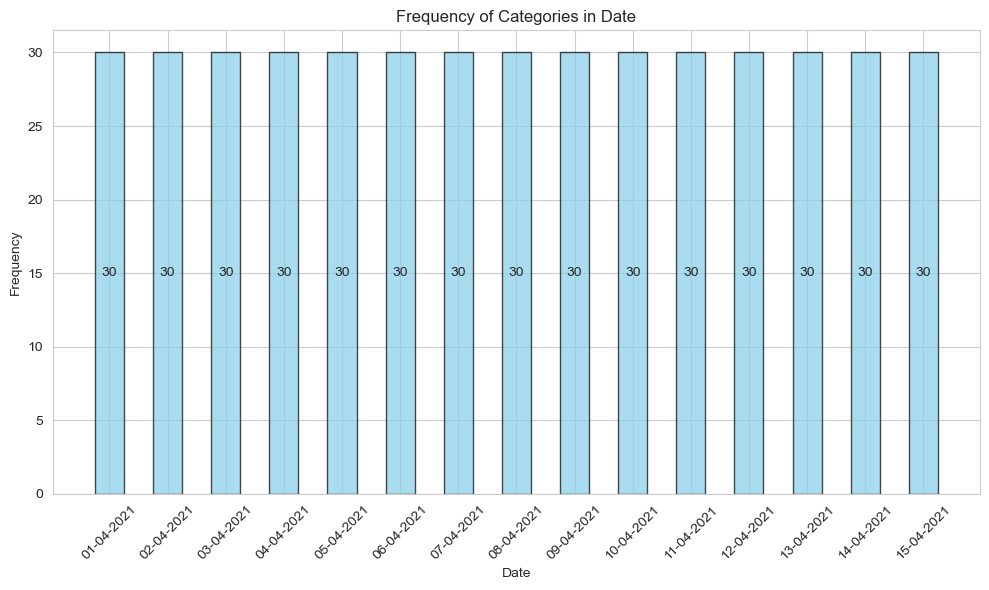

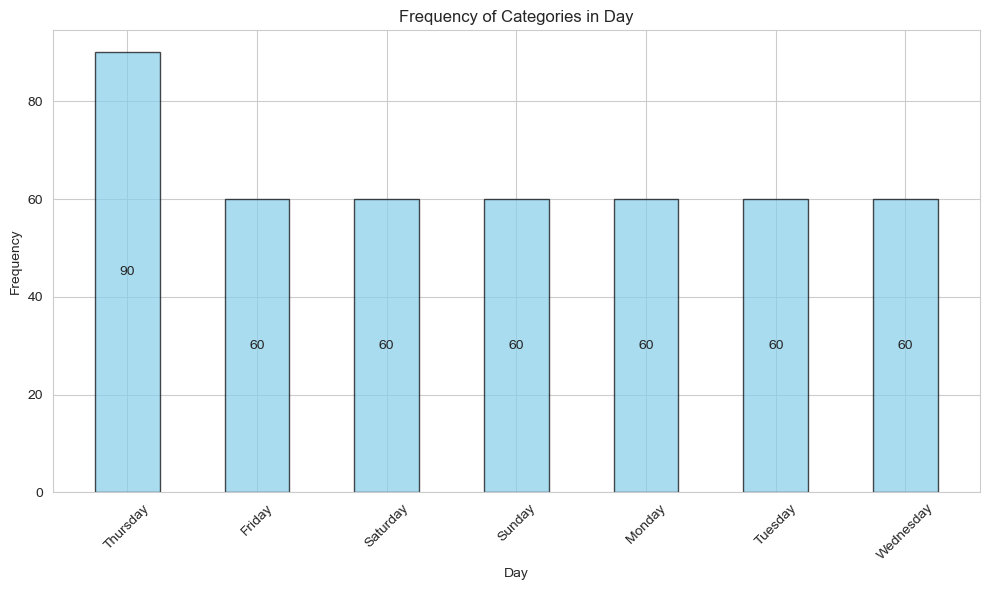

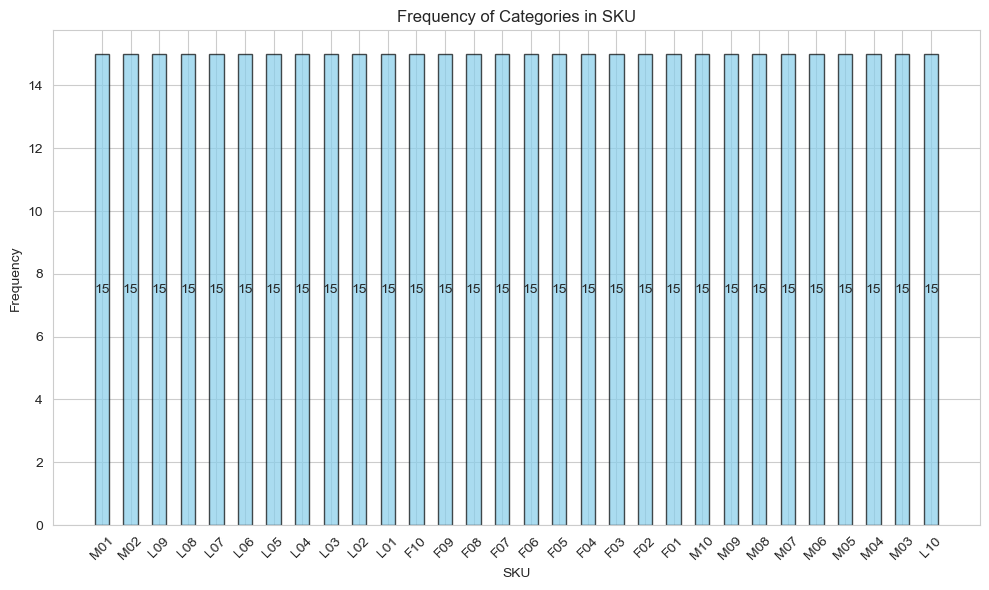

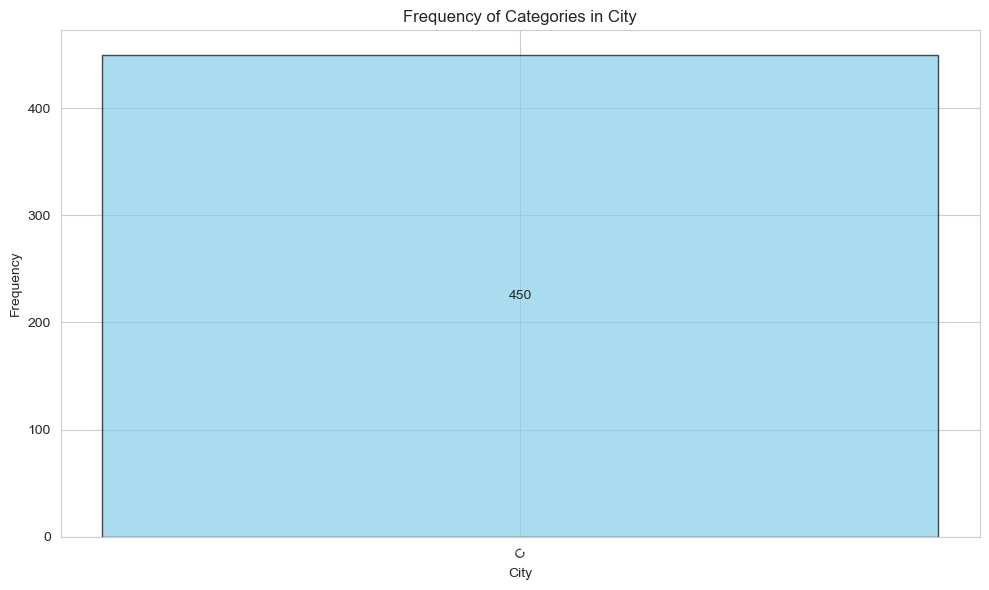

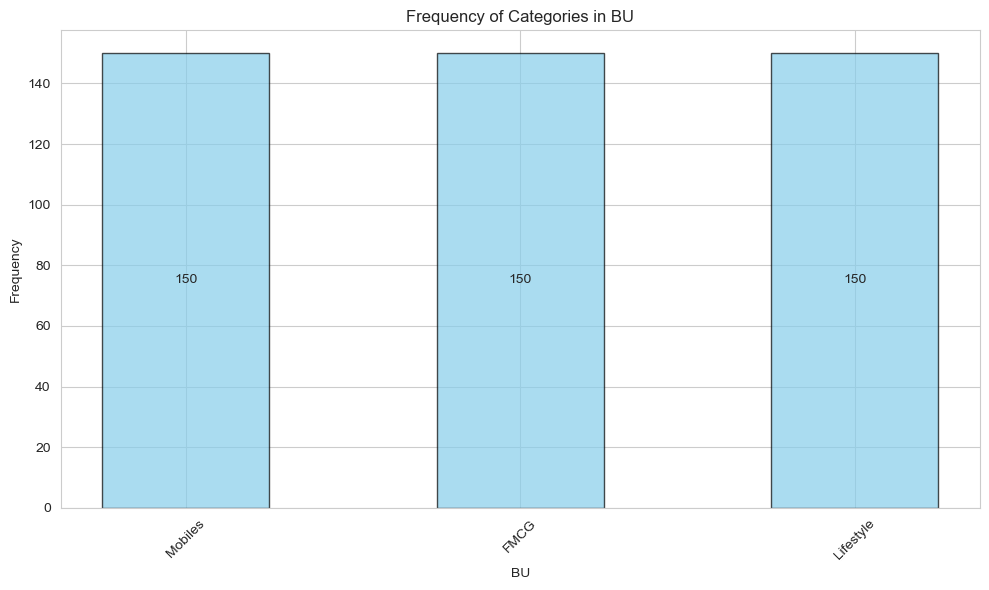

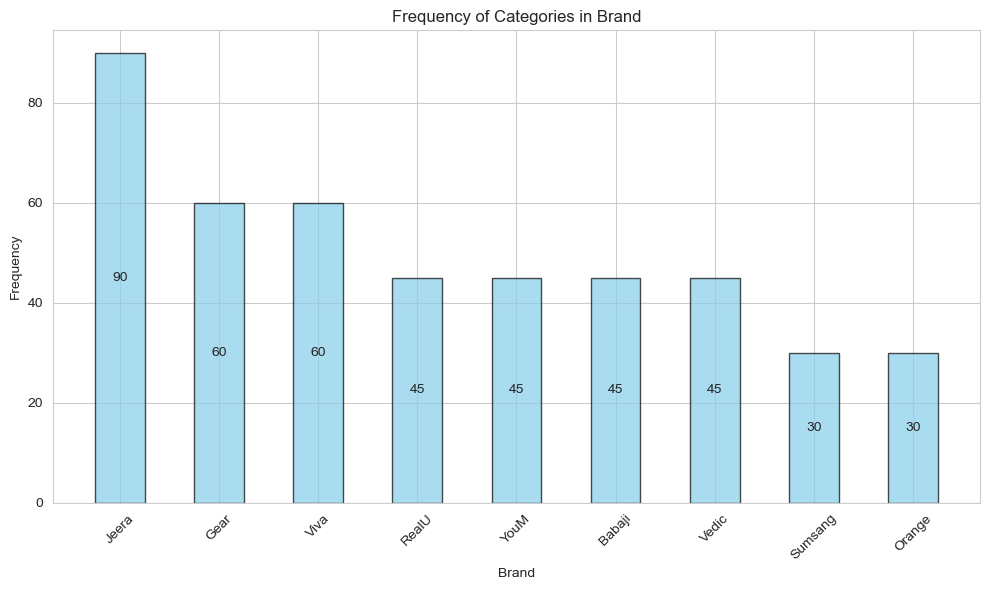

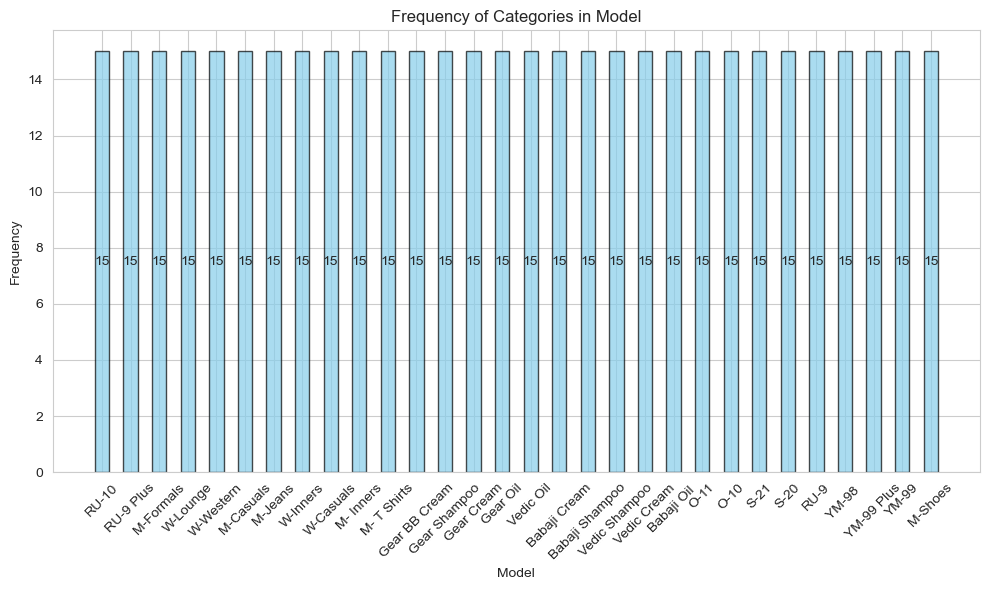

In [87]:
for col in categorical_columns:
    plt.figure(figsize=(10, 6))

    # Create the bar chart
    ax = plt.bar(df[col].value_counts().index,
                 df[col].value_counts().values,
                 color='skyblue', edgecolor='black',
                 linewidth=1, alpha=0.7, width=0.5)

    # Add the actual values inside the bars using the inbuilt bar_label
    plt.gca().bar_label(plt.gca().containers[0], label_type='center')

    # Set titles and labels
    plt.title(f'Frequency of Categories in {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

    # Adjust x-axis labels for better readability
    plt.xticks(rotation=45)

    # Display the plot
    plt.tight_layout()
    plt.show()

### Standardization of Numerical Variables
- **Objective**: To scale numerical variables for uniformity, improving the dataset’s suitability for analytical models.
- **Steps**:
    - Explain the concept of standardization (z-score normalization).
    - Standardize the numerical columns using the formula: z = (x - mean) / std_dev.
    - Show before and after comparisons of the data distributions.


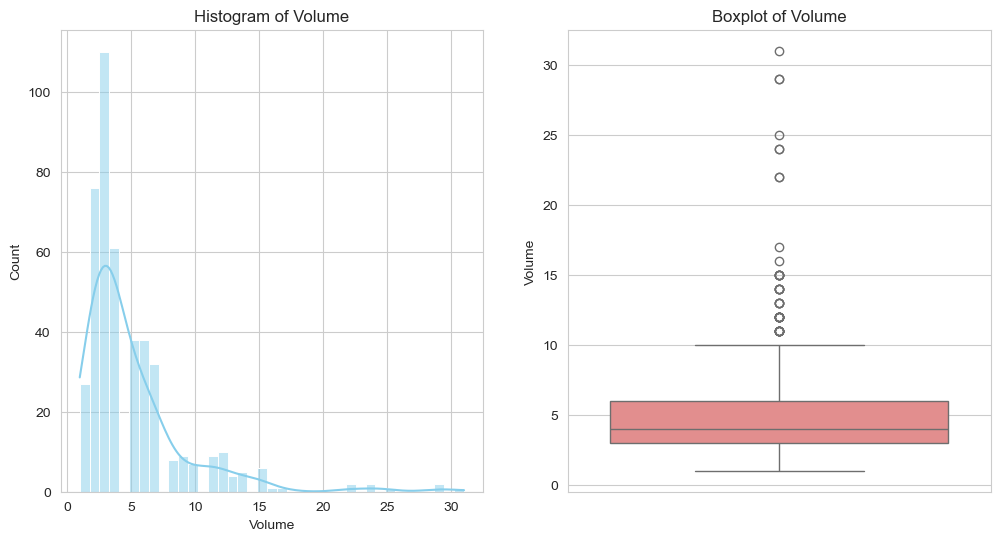

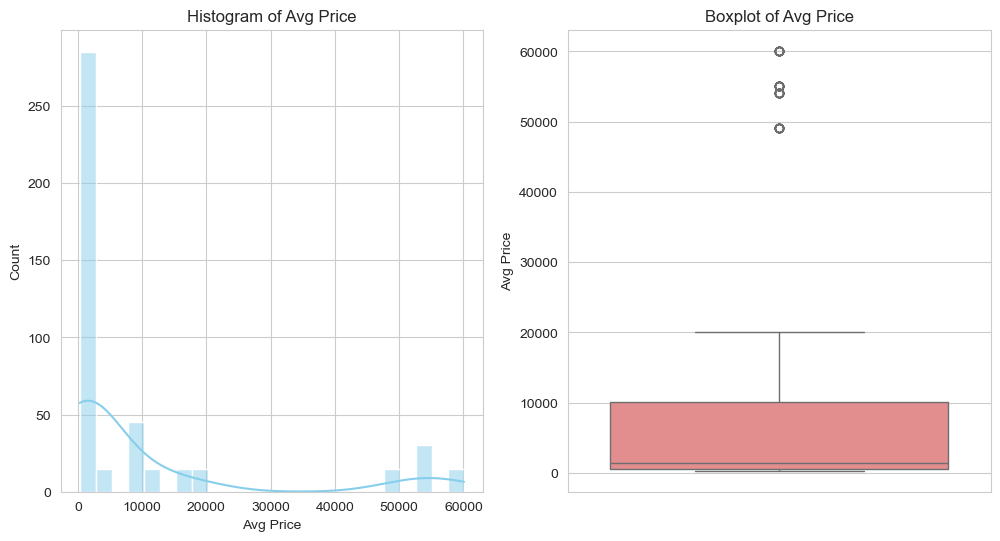

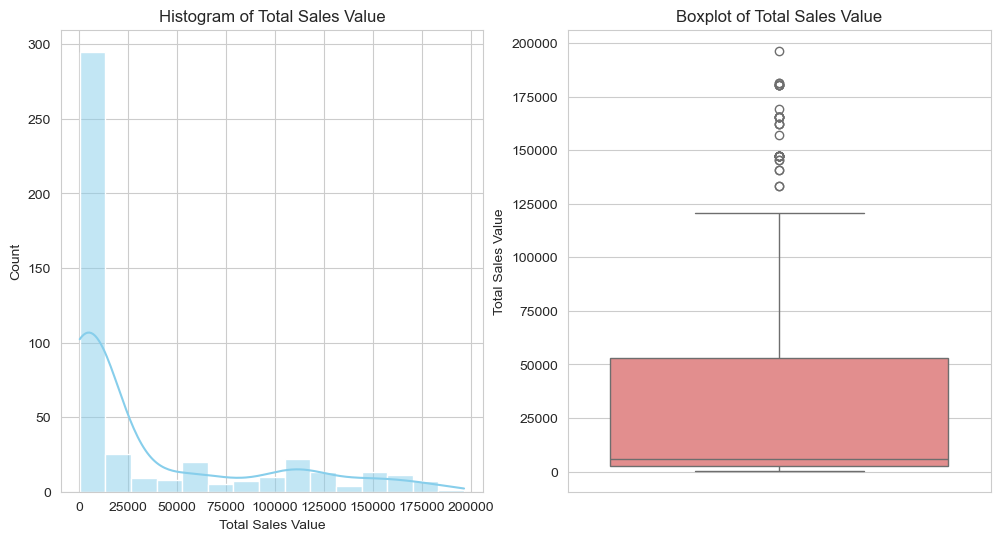

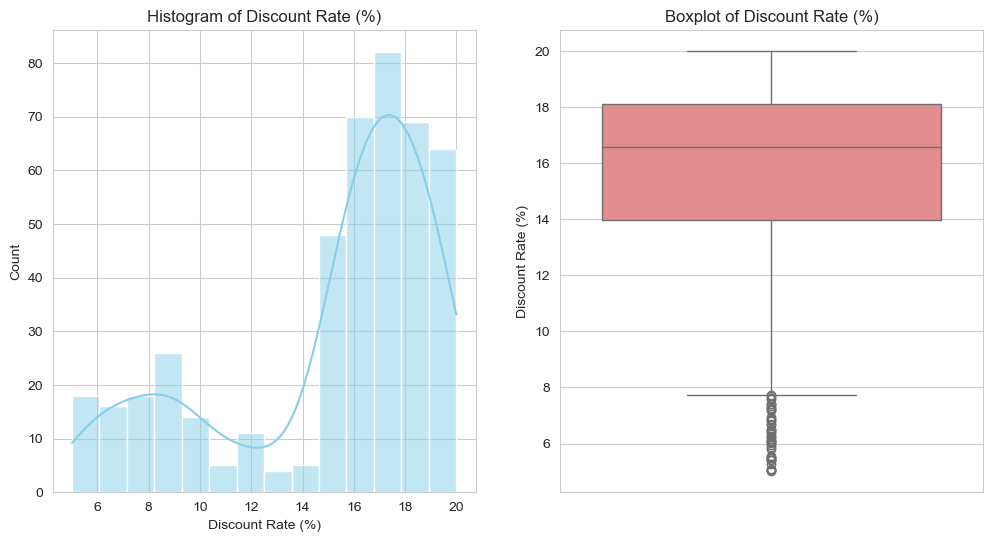

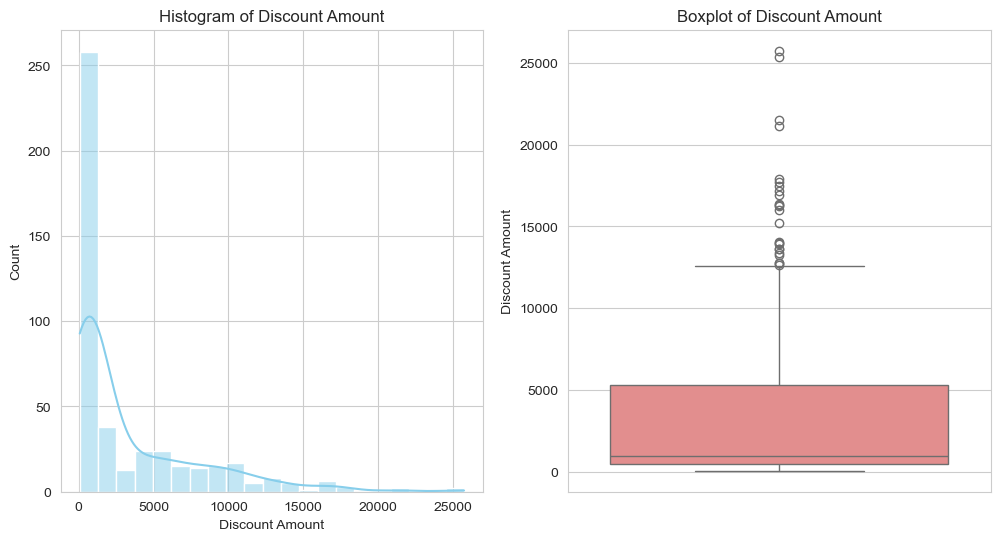

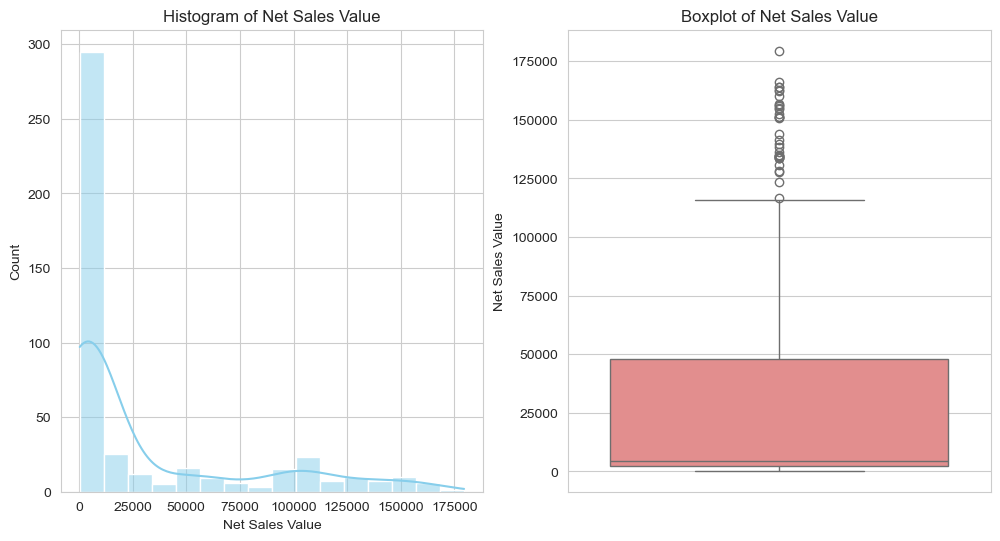

In [96]:
#histograms for numerical columns before standardization
import seaborn as sns
for column in numerical_cols:
    plt.figure(figsize=(12, 6))

    # Histogram to visualize distribution
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st subplot
    sns.histplot(df[column], kde=True, color='skyblue')
    plt.title(f'Histogram of {column}')

    #boxplot to visualize outliers
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd subplot
    sns.boxplot(y=df[column], color='lightcoral')
    plt.title(f'Boxplot of {column}')

In [90]:
# Standardization of numerical columns
df_standardized = df.copy() # create a copy of the original dataframe
for col in numerical_cols:
    mean = df[col].mean()
    std_dev = df[col].std()
    df_standardized[col] = (df[col] - mean) / std_dev # standardize the column values

In [91]:
# after standardization
df_standardized[numerical_cols].describe()

,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,4.500000e+02,4.500000e+02,4.500000e+02,4.500000e+02,4.500000e+02,450.000000
mean,6.710681e-17,3.947460e-17,1.184238e-17,-3.157968e-17,-5.526444e-17,0.000000
std,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,1.000000
min,-9.610229e-01,-5.621398e-01,-6.611811e-01,-2.404259e+00,-7.266945e-01,-0.650134
25%,-4.883887e-01,-5.524605e-01,-6.156681e-01,-2.819928e-01,-6.399340e-01,-0.609684
50%,-2.520716e-01,-4.979801e-01,-5.563034e-01,3.370428e-01,-5.227531e-01,-0.556283
75%,2.205626e-01,-1.954841e-02,3.836378e-01,7.011977e-01,4.368156e-01,0.374937
max,6.128490e+00,2.745953e+00,3.217313e+00,1.146084e+00,4.964968e+00,3.214958


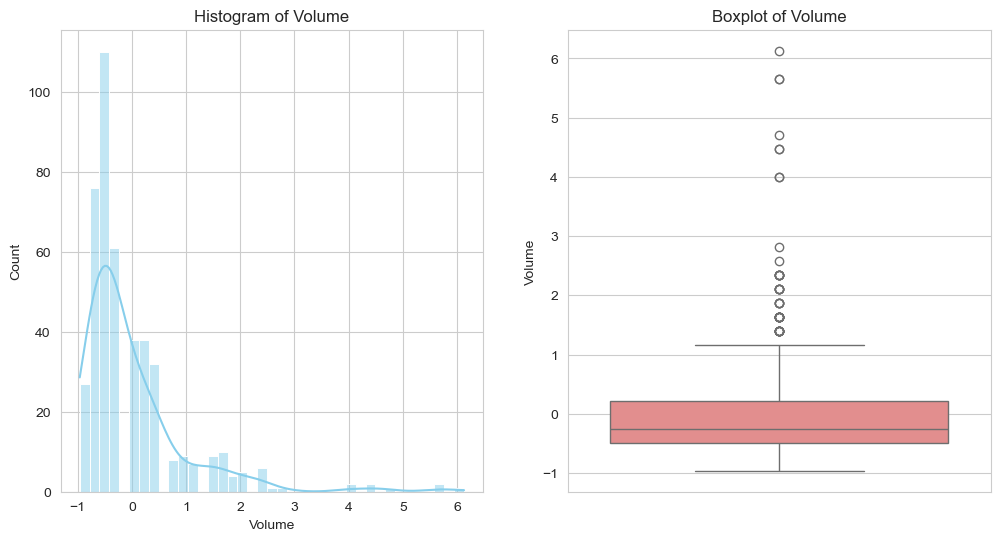

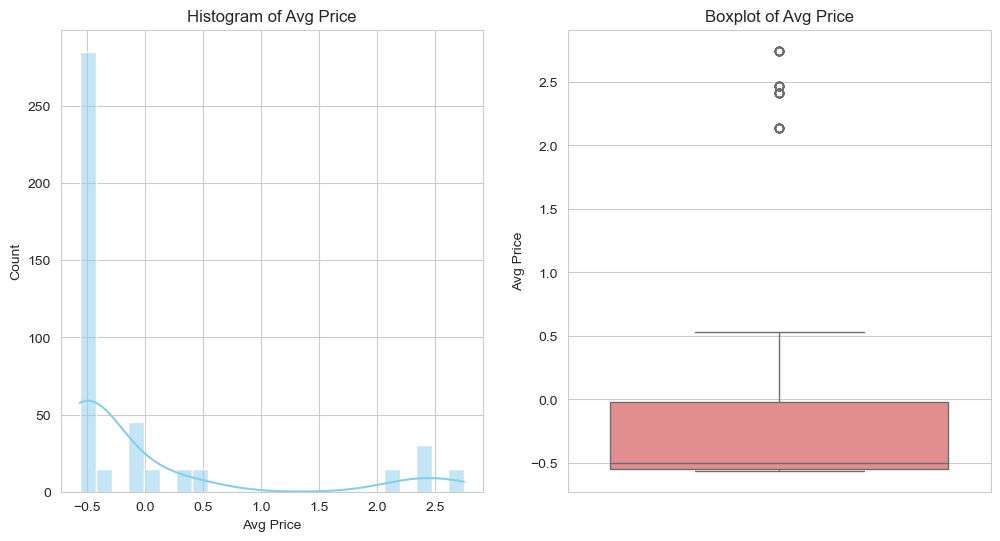

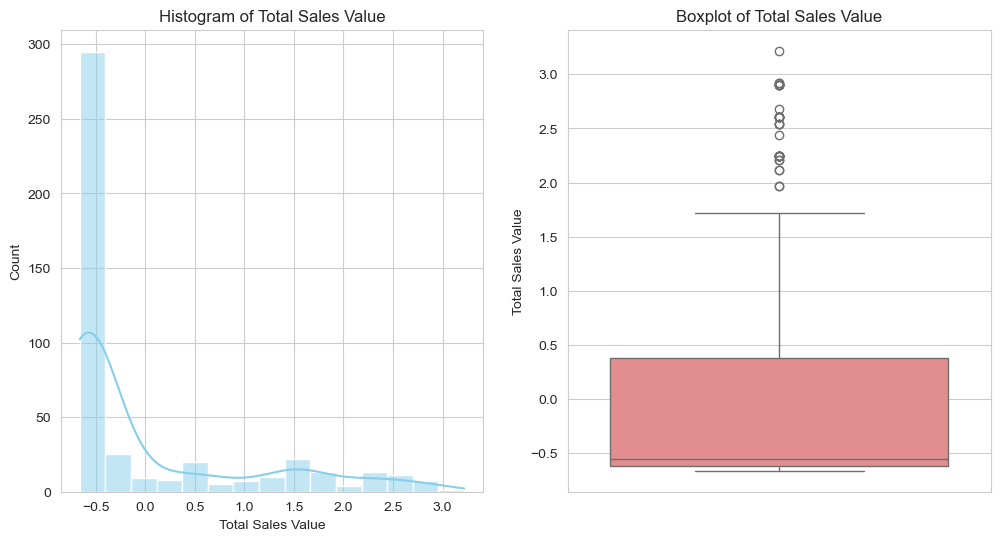

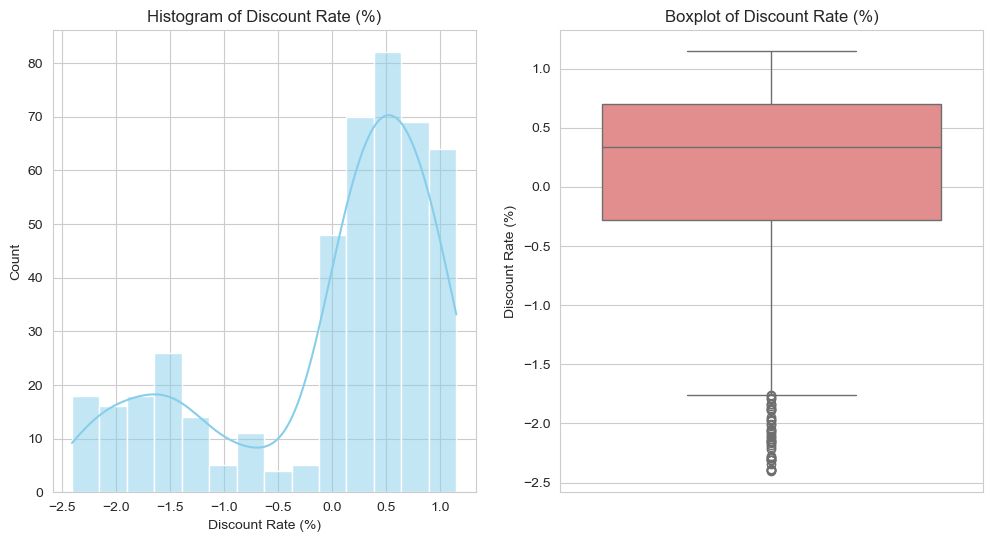

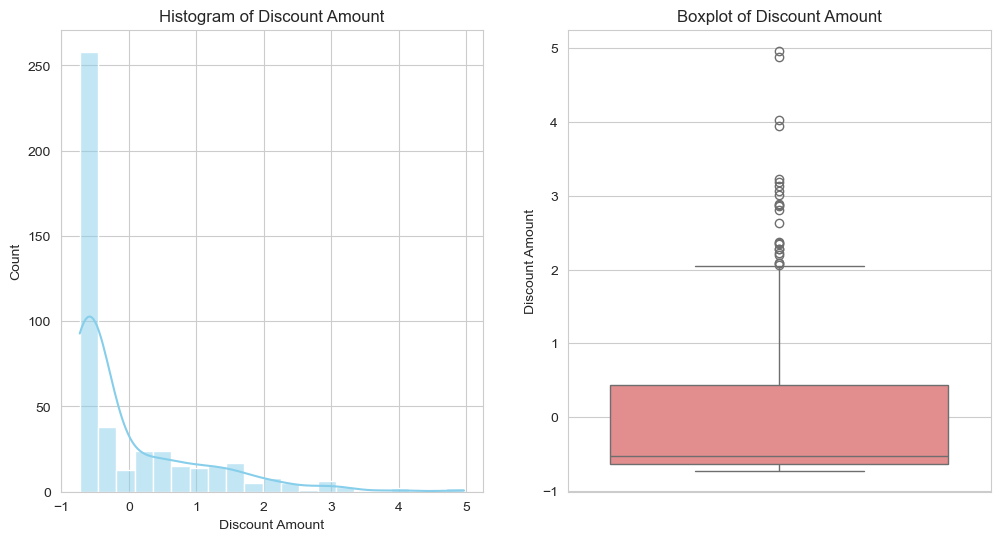

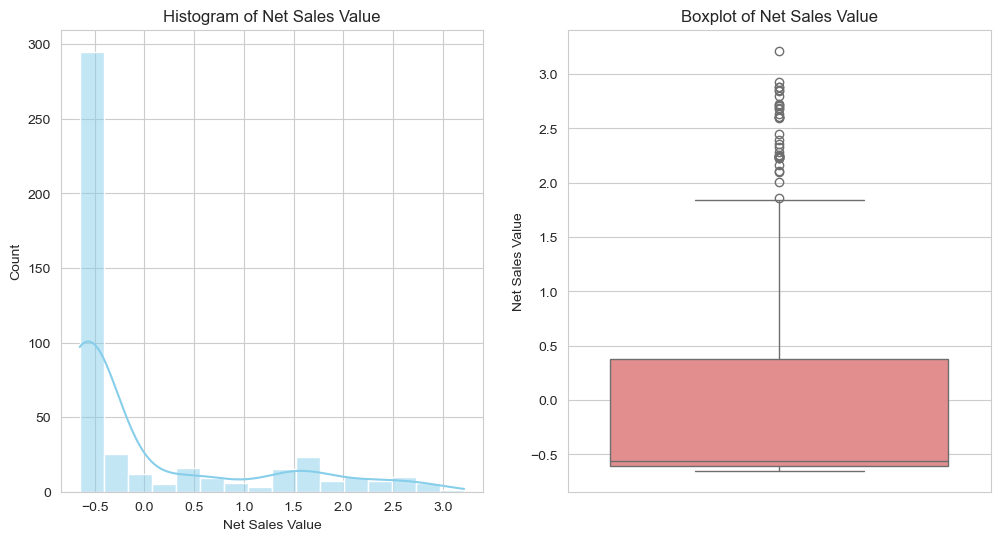

In [108]:
#histograms for all columns after standardization
import seaborn as sns
for column in numerical_cols:
    plt.figure(figsize=(12, 6))

    # Histogram to visualize distribution
    plt.subplot(1, 2, 1) # 1 row, 2 columns, 1st subplot
    sns.histplot(df_standardized[column], kde=True, color='skyblue')
    plt.title(f'Histogram of {column}')

    #boxplot to visualize outliers
    plt.subplot(1, 2, 2) # 1 row, 2 columns, 2nd subplot
    sns.boxplot(y=df_standardized[column], color='lightcoral')
    plt.title(f'Boxplot of {column}')

### Inference:
#### Before standardization, the data shows varied scales, distributions, and outliers that could bias or distort the results of many models.
#### After standardization, the data is uniformly scaled, outliers are normalized, and the features are on an equal footing, enabling more reliable and interpretable results from most machine learning models.


### Conversion of Categorical Data into Dummy Variables
- **Objective**: To transform categorical variables into a format that can be provided to ML algorithms.
  
- **Steps**:
   1. **Discuss the need for converting categorical data into dummy variables (one-hot encoding)**:
     - Categorical data cannot be directly used by most machine learning algorithms because they expect numerical inputs.
     - One-hot encoding is a method that converts each unique category into a separate binary column.
     
  2. **Apply one-hot encoding to the categorical columns, creating binary (0 or 1) columns for each category**:
     - Implement the code to apply one-hot encoding to categorical columns.
  
  3. **Display a portion of the transformed dataset**:
     - Display the first few rows of the dataset after applying one-hot encoding.


In [111]:
import pandas as pd

# Step 1: Check for boolean columns and convert them to integers (0/1)
for col in df.columns:
    if df[col].dtype == 'bool':  # Check if the column is of boolean type
        df[col] = df[col].astype(int)  # Convert boolean to integer (0/1)

# Step 2: Identify categorical columns (that are not numerical)
categorical_columns = df.select_dtypes(exclude=[int, float]).columns

# Step 3: Apply one-hot encoding to categorical columns
df_encoded = pd.get_dummies(df, columns=categorical_columns, drop_first=True)

# Step 4: Display a portion of the transformed dataset
df_encoded.head()


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value,Date_02-04-2021,Date_03-04-2021,Date_04-04-2021,Date_05-04-2021,...,Model_Vedic Cream,Model_Vedic Oil,Model_Vedic Shampoo,Model_W-Casuals,Model_W-Inners,Model_W-Lounge,Model_W-Western,Model_YM-98,Model_YM-99,Model_YM-99 Plus
0,15,12100,181500,11.654820,21153.498820,160346.501180,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,10,10100,101000,11.560498,11676.102961,89323.897039,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,7,16100,112700,9.456886,10657.910157,102042.089843,False,False,False,False,...,False,False,False,False,False,False,False,False,True,False
3,6,20100,120600,6.935385,8364.074702,112235.925298,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,3,8100,24300,17.995663,4372.946230,19927.053770,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
